# IT3091 — Group 30 — Member 1: Problem Framing, Workflow & Data Understanding

**Scenario:** Code 0, Retail & E-commerce
**Dataset:** UCI Online Retail (ID 352) — https://archive.ics.uci.edu/dataset/352/online-retail
**Primary lens:** Customer Segmentation Based on Purchasing Behaviour

---

### Where this notebook lives

```
WE-AI-30-ML-Assignment/
├── data/raw/Online Retail.xlsx        <- put the downloaded dataset here
├── members/member-1/
│   ├── notebooks/eda.ipynb            <- THIS FILE
│   ├── figures/                       <- charts are saved here (development)
│   └── docs/                          <- CSV logs are saved here (development)
├── figures/eda/                       <- accepted charts are promoted here
└── docs/data-dictionary/ , docs/eda-insight-log/   <- accepted logs promoted here
```

Development outputs go in **your own member folder**. The last section promotes the
accepted ones to the shared `docs/` and `figures/` folders, which keeps the group's
review step clean.

### How to use it

Run every cell top to bottom. Each question ends with a printed
**Observation / Meaning / Impact** block. Copy those into your EDA insight log —
but rewrite them in your own words once you have looked at the chart.


## 0. Setup and folder paths

In [5]:
# If you are on Google Colab, uncomment these two lines to reach the project in Drive.
# from google.colab import drive
# drive.mount('/content/drive')

from pathlib import Path
import os

def find_project_root(start: Path) -> Path:
    """Walk upwards until we find the folder containing data/ and members/."""
    for folder in [start, *start.parents]:
        if (folder / "data").is_dir() and (folder / "members").is_dir():
            return folder
    raise FileNotFoundError(
        "Could not find the project root. Set ROOT manually, e.g.\n"
        "ROOT = Path('/content/drive/MyDrive/WE-AI-30-ML-Assignment')"
    )

# ROOT = Path('/content/drive/MyDrive/WE-AI-30-ML-Assignment')   # <- set manually if needed
ROOT = find_project_root(Path.cwd())

RAW        = ROOT / "data" / "raw"
MY_FIGURES = ROOT / "members" / "member-1" / "figures"
MY_DOCS    = ROOT / "members" / "member-1" / "docs"
CACHE      = ROOT / "members" / "member-1" / "cache"

SHARED_FIG  = ROOT / "figures" / "eda"
SHARED_DICT = ROOT / "docs" / "data-dictionary"
SHARED_LOG  = ROOT / "docs" / "eda-insight-log"

for d in (RAW, MY_FIGURES, MY_DOCS, CACHE, SHARED_FIG, SHARED_DICT, SHARED_LOG):
    d.mkdir(parents=True, exist_ok=True)

print("Project root :", ROOT)
print("Raw data     :", RAW)
print("My figures   :", MY_FIGURES)
print("My docs      :", MY_DOCS)

Project root : c:\Users\vasan\OneDrive\Desktop\Machine Learning project\WE-AI-30-ML-Assignment
Raw data     : c:\Users\vasan\OneDrive\Desktop\Machine Learning project\WE-AI-30-ML-Assignment\data\raw
My figures   : c:\Users\vasan\OneDrive\Desktop\Machine Learning project\WE-AI-30-ML-Assignment\members\member-1\figures
My docs      : c:\Users\vasan\OneDrive\Desktop\Machine Learning project\WE-AI-30-ML-Assignment\members\member-1\docs


In [9]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib, json, datetime

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

INSIGHTS = []   # collected automatically as you run the notebook

def save(name):
    """Save the current chart into your member figures folder."""
    plt.tight_layout()
    path = MY_FIGURES / f"{name}.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print("saved ->", path.relative_to(ROOT))

def insight(ref, topic, obs, meaning, impact):
    INSIGHTS.append({"Ref": ref, "Topic": topic, "Observation": obs,
                     "Meaning": meaning, "Impact": impact})
    print(f"[{ref}] {topic}")
    print("OBSERVATION:", obs)
    print("MEANING    :", meaning)
    print("IMPACT     :", impact)

### Load the data and record its fingerprint

Put `Online Retail.xlsx` in `data/raw/` before running this.

The fingerprint is a SHA-256 hash — a long code unique to that exact file. It proves
every member used the identical data, and the reproducibility criterion (10 marks) asks
for it. The hash is written to `docs/reproducibility/` for the final report.

In [6]:
RAW_FILE = RAW / "Online Retail.xlsx"

if not RAW_FILE.exists():
    candidates = list(RAW.glob("*.xlsx")) + list(RAW.glob("*.csv"))
    if candidates:
        RAW_FILE = candidates[0]
        print("Using:", RAW_FILE.name)
    else:
        raise FileNotFoundError(
            f"No dataset found in {RAW}.\n"
            "Download 'Online Retail.xlsx' from "
            "https://archive.ics.uci.edu/dataset/352/online-retail and put it there."
        )

FINGERPRINT = hashlib.sha256(RAW_FILE.read_bytes()).hexdigest()

CACHE_FILE = CACHE / "online_retail_raw.pkl"
if CACHE_FILE.exists():
    df = pd.read_pickle(CACHE_FILE)
    print("Loaded from cache (fast).")
else:
    df = pd.read_excel(RAW_FILE)     # 1-2 minutes, it is a 23 MB Excel file
    df.to_pickle(CACHE_FILE)
    print("Loaded from Excel and cached for next time.")

print("\nFile       :", RAW_FILE.name)
print("SHA-256    :", FINGERPRINT)
print("Rows, cols :", df.shape)
print("Date range :", df.InvoiceDate.min(), "to", df.InvoiceDate.max())

Loaded from Excel and cached for next time.

File       : Online Retail.xlsx
SHA-256    : 43465a06f2ccf7c8b5bd2892bc7defb52f97487934fe93b16ae4c3936424676d
Rows, cols : (541909, 8)
Date range : 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [8]:
# Write the fingerprint record for the reproducibility section
repro_dir = ROOT / "docs" / "reproducibility"
repro_dir.mkdir(parents=True, exist_ok=True)

record = {
    "dataset_name": "Online Retail (UCI ML Repository, ID 352)",
    "source_url": "https://archive.ics.uci.edu/dataset/352/online-retail",
    "file_name": RAW_FILE.name,
    "file_size_bytes": RAW_FILE.stat().st_size,
    "sha256": FINGERPRINT,
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "date_min": str(df.InvoiceDate.min()),
    "date_max": str(df.InvoiceDate.max()),
    "recorded_by": "Member 1",
    "recorded_on": datetime.date.today().isoformat(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
}
(repro_dir / "dataset_fingerprint.json").write_text(json.dumps(record, indent=2))
print(json.dumps(record, indent=2))

{
  "dataset_name": "Online Retail (UCI ML Repository, ID 352)",
  "source_url": "https://archive.ics.uci.edu/dataset/352/online-retail",
  "file_name": "Online Retail.xlsx",
  "file_size_bytes": 23715344,
  "sha256": "43465a06f2ccf7c8b5bd2892bc7defb52f97487934fe93b16ae4c3936424676d",
  "rows": 541909,
  "columns": 8,
  "date_min": "2010-12-01 08:26:00",
  "date_max": "2011-12-09 12:50:00",
  "recorded_by": "Member 1",
  "recorded_on": "2026-09-13",
  "pandas_version": "3.0.5",
  "numpy_version": "2.5.3"
}


## 1. What does one row mean?

A marker checks this first. A row is **one product line on one invoice** — not one
customer and not one order. A single invoice spans several rows.

In [10]:
display(df.head(8))

example = df.InvoiceNo.value_counts().index[0]
print(f"\nInvoice {example} spans several rows:")
display(df[df.InvoiceNo == example].head(6))
print(f"That invoice has {(df.InvoiceNo == example).sum()} product lines.")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,"17,850.00",United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,"17,850.00",United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,"17,850.00",United Kingdom



Invoice 573585 spans several rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
430237,573585,11001,ASSTD DESIGN RACING CAR PEN,2,2011-10-31 14:41:00,3.29,NaN,United Kingdom
430238,573585,15036,ASSORTED COLOURS SILK FAN,15,2011-10-31 14:41:00,1.63,NaN,United Kingdom
430239,573585,15039,SANDALWOOD FAN,15,2011-10-31 14:41:00,1.63,NaN,United Kingdom
430240,573585,15056BL,EDWARDIAN PARASOL BLACK,1,2011-10-31 14:41:00,12.46,NaN,United Kingdom
430241,573585,15056N,EDWARDIAN PARASOL NATURAL,1,2011-10-31 14:41:00,12.46,NaN,United Kingdom
430242,573585,15058C,ICE CREAM DESIGN GARDEN PARASOL,1,2011-10-31 14:41:00,10.79,NaN,United Kingdom


That invoice has 1114 product lines.


In [11]:
print("Rows (product lines):", f"{len(df):,}")
print("Unique invoices     :", f"{df.InvoiceNo.nunique():,}")
print("Unique customers    :", f"{df.CustomerID.nunique():,}")
print("Unique products     :", f"{df.StockCode.nunique():,}")
print("Countries           :", df.Country.nunique())

Rows (product lines): 541,909
Unique invoices     : 25,900
Unique customers    : 4,372
Unique products     : 4,070
Countries           : 38


## 2. Data dictionary (raw fields)

In [12]:
dd = pd.DataFrame({
    "Column": df.columns,
    "Type": [str(t) for t in df.dtypes],
    "Missing": [df[c].isna().sum() for c in df.columns],
    "Missing %": [round(df[c].isna().mean()*100, 2) for c in df.columns],
    "Distinct": [df[c].nunique() for c in df.columns],
    "Example": [df[c].dropna().iloc[0] for c in df.columns],
})
dd["Meaning"] = [
    "Invoice number. Starting with 'C' means the order was cancelled",
    "Product code",
    "Product name",
    "How many items were bought (negative = returned)",
    "Date and time of the sale",
    "Price of one item, in British pounds",
    "Customer number",
    "Country where the customer lives",
]
display(dd)
dd.to_csv(MY_DOCS / "data_dictionary_raw.csv", index=False)
print("saved ->", (MY_DOCS / "data_dictionary_raw.csv").relative_to(ROOT))

,Column,Type,Missing,Missing %,Distinct,Example,Meaning
0,InvoiceNo,object,0,0.00,25900,536365,Invoice number. Starting with 'C' means the or...
1,StockCode,object,0,0.00,4070,85123A,Product code
2,Description,object,1454,0.27,4223,WHITE HANGING HEART T-LIGHT HOLDER,Product name
3,Quantity,int64,0,0.00,722,6,How many items were bought (negative = returned)
4,InvoiceDate,datetime64[us],0,0.00,23260,2010-12-01 08:26:00,Date and time of the sale
5,UnitPrice,float64,0,0.00,1630,2.55,"Price of one item, in British pounds"
6,CustomerID,float64,135080,24.93,4372,"17,850.00",Customer number
7,Country,str,0,0.00,38,United Kingdom,Country where the customer lives


saved -> members\member-1\docs\data_dictionary_raw.csv


## Q1. How many rows have no customer number?

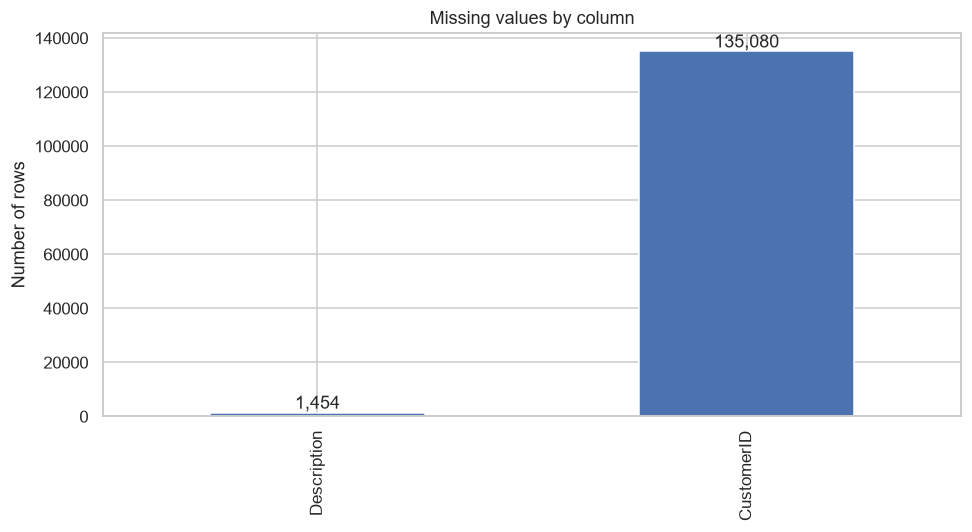

saved -> members\member-1\figures\q1_missing_values.png
Rows with no CustomerID: 135,080  (24.9%)
Rows usable for customer work: 406,829
[Q1] Missing CustomerID
OBSERVATION: 135,080 rows (24.9%) have no CustomerID.
MEANING    : These are likely guest or till sales that cannot be traced to a person.
IMPACT     : M2 drops them for customer-level work. M1 records the limitation: our segments describe identified customers only.


In [13]:
miss = df.isna().sum()
miss = miss[miss > 0]

ax = miss.plot(kind="bar", color="#4C72B0")
ax.set_title("Missing values by column")
ax.set_ylabel("Number of rows")
for i, v in enumerate(miss):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
save("q1_missing_values")

no_cust = df.CustomerID.isna().sum()
print(f"Rows with no CustomerID: {no_cust:,}  ({no_cust/len(df)*100:.1f}%)")
print(f"Rows usable for customer work: {len(df)-no_cust:,}")

insight("Q1", "Missing CustomerID",
 f"{no_cust:,} rows ({no_cust/len(df)*100:.1f}%) have no CustomerID.",
 "These are likely guest or till sales that cannot be traced to a person.",
 "M2 drops them for customer-level work. M1 records the limitation: our segments describe identified customers only.")

## Q2. Is spending per customer even or lopsided?

This drives the single most important preprocessing decision in the project.

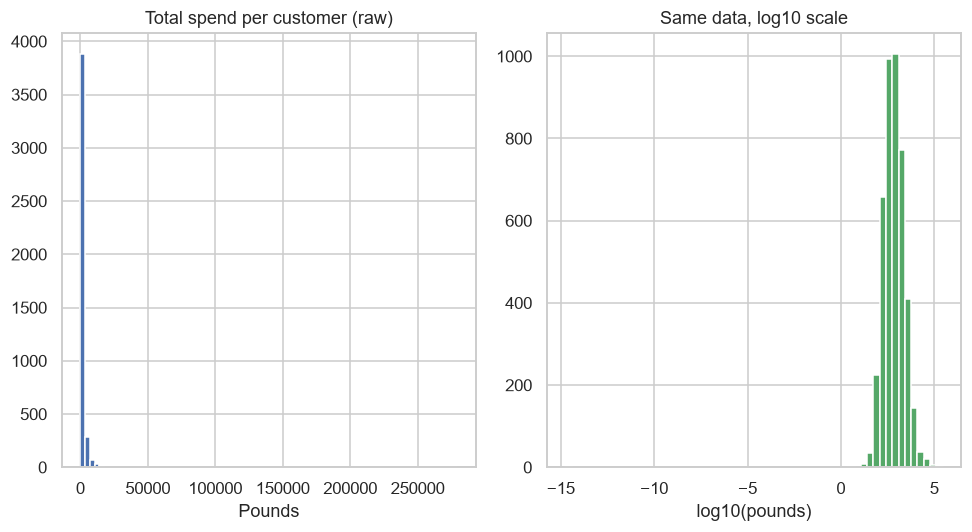

saved -> members\member-1\figures\q2_spend_skew.png
count     4,322.00
mean      1,923.48
std       8,263.13
min           0.00
25%         302.29
50%         657.55
75%       1,625.74
max     279,489.02
Name: LineTotal, dtype: float64

Skewness: 21.6  (0 = symmetric)
Top 1% of customers account for 29.7% of revenue.
[Q2] Spend skew
OBSERVATION: Spend is extremely right-skewed (skewness 21.6); the top 1% of customers bring in 29.7% of revenue.
MEANING    : A small number of wholesalers spend far more than ordinary customers.
IMPACT     : M2 should log-transform Monetary before scaling. M3 must note K-Means uses distances, so untransformed spend would let a few wholesalers dominate every cluster.


In [14]:
df["LineTotal"] = df.Quantity * df.UnitPrice
spend = df.dropna(subset=["CustomerID"]).groupby("CustomerID").LineTotal.sum()
spend_pos = spend[spend > 0]

fig, ax = plt.subplots(1, 2)
ax[0].hist(spend_pos, bins=80, color="#4C72B0")
ax[0].set_title("Total spend per customer (raw)")
ax[0].set_xlabel("Pounds")
ax[1].hist(np.log10(spend_pos), bins=60, color="#55A868")
ax[1].set_title("Same data, log10 scale")
ax[1].set_xlabel("log10(pounds)")
save("q2_spend_skew")

print(spend_pos.describe())
top1 = spend_pos.nlargest(max(1, int(len(spend_pos)*0.01))).sum()
print(f"\nSkewness: {spend_pos.skew():.1f}  (0 = symmetric)")
print(f"Top 1% of customers account for {top1/spend_pos.sum()*100:.1f}% of revenue.")

insight("Q2", "Spend skew",
 f"Spend is extremely right-skewed (skewness {spend_pos.skew():.1f}); the top 1% of customers bring in {top1/spend_pos.sum()*100:.1f}% of revenue.",
 "A small number of wholesalers spend far more than ordinary customers.",
 "M2 should log-transform Monetary before scaling. M3 must note K-Means uses distances, so untransformed spend would let a few wholesalers dominate every cluster.")

## Q3. How many customers bought only once?

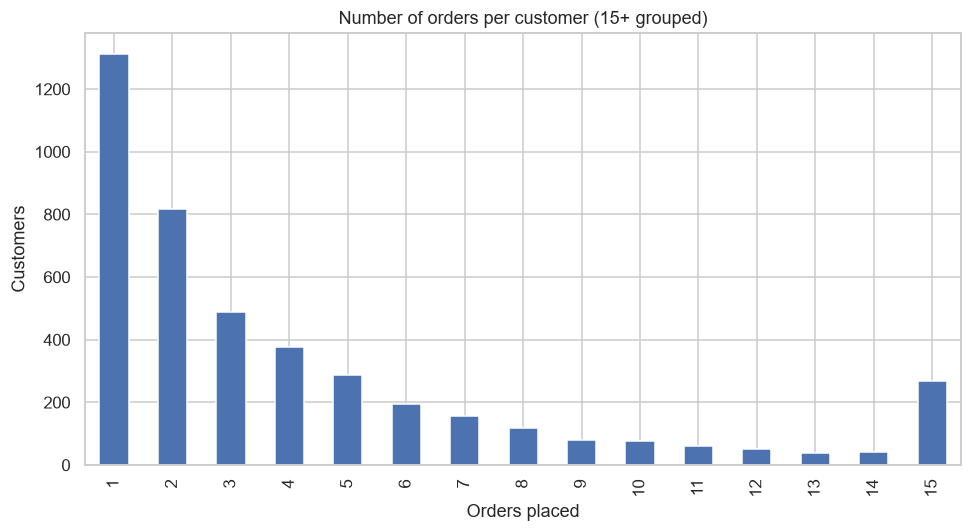

saved -> members\member-1\figures\q3_orders_per_customer.png
Customers with exactly 1 order: 1,313 (30.0%)
Median orders per customer    : 3
Most orders by one customer   : 248
[Q3] One-time buyers
OBSERVATION: 1,313 customers (30.0%) placed only one order.
MEANING    : A large one-time group exists alongside a smaller repeat-buying group.
IMPACT     : M3 should expect at least one cluster of one-time low-value customers. M4 should verify this group really stays away after the cut-off date.


In [15]:
orders = df.dropna(subset=["CustomerID"]).groupby("CustomerID").InvoiceNo.nunique()

ax = orders.clip(upper=15).value_counts().sort_index().plot(kind="bar", color="#4C72B0")
ax.set_title("Number of orders per customer (15+ grouped)")
ax.set_xlabel("Orders placed")
ax.set_ylabel("Customers")
save("q3_orders_per_customer")

once = (orders == 1).sum()
print(f"Customers with exactly 1 order: {once:,} ({once/len(orders)*100:.1f}%)")
print(f"Median orders per customer    : {orders.median():.0f}")
print(f"Most orders by one customer   : {orders.max()}")

insight("Q3", "One-time buyers",
 f"{once:,} customers ({once/len(orders)*100:.1f}%) placed only one order.",
 "A large one-time group exists alongside a smaller repeat-buying group.",
 "M3 should expect at least one cluster of one-time low-value customers. M4 should verify this group really stays away after the cut-off date.")

## Q4. When did customers last buy? (Recency)

Cut-off date for building segments: 2011-09-09
Data continues to: 2011-12-09 12:50:00
Days available after cut-off: 91


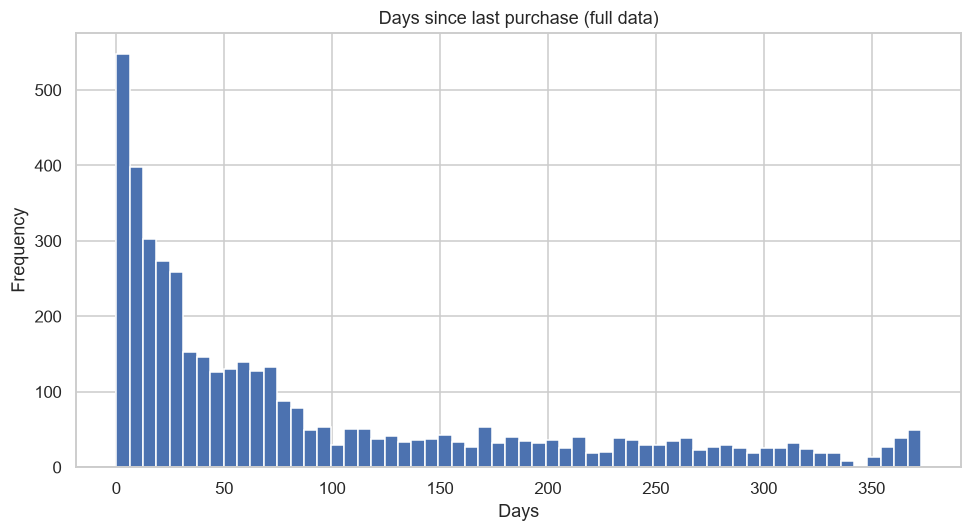

saved -> members\member-1\figures\q4_recency.png
count   4,372.00
mean       91.05
std       100.77
min         0.00
25%        16.00
50%        49.00
75%       142.00
max       373.00
Name: InvoiceDate, dtype: float64
[Q4] Recency spread
OBSERVATION: Recency ranges from 0 to 373 days; the median is 49 days.
MEANING    : Many customers have been quiet a long time while others bought very recently.
IMPACT     : Recency separates customers well, so M3 keeps it as a clustering feature. M4 uses the 90 days after 9 Sep 2011 to test whether 'lost' customers really stayed away.


In [16]:
CUTOFF = pd.Timestamp("2011-09-09")
print("Cut-off date for building segments:", CUTOFF.date())
print("Data continues to:", df.InvoiceDate.max())
print("Days available after cut-off:", (df.InvoiceDate.max() - CUTOFF).days)

last = df.dropna(subset=["CustomerID"]).groupby("CustomerID").InvoiceDate.max()
recency = (df.InvoiceDate.max() - last).dt.days

ax = recency.plot(kind="hist", bins=60, color="#4C72B0")
ax.set_title("Days since last purchase (full data)")
ax.set_xlabel("Days")
save("q4_recency")

print(recency.describe())

insight("Q4", "Recency spread",
 f"Recency ranges from {recency.min()} to {recency.max()} days; the median is {recency.median():.0f} days.",
 "Many customers have been quiet a long time while others bought very recently.",
 "Recency separates customers well, so M3 keeps it as a clustering feature. M4 uses the 90 days after 9 Sep 2011 to test whether 'lost' customers really stayed away.")

## Q5. How do sales change over the year?

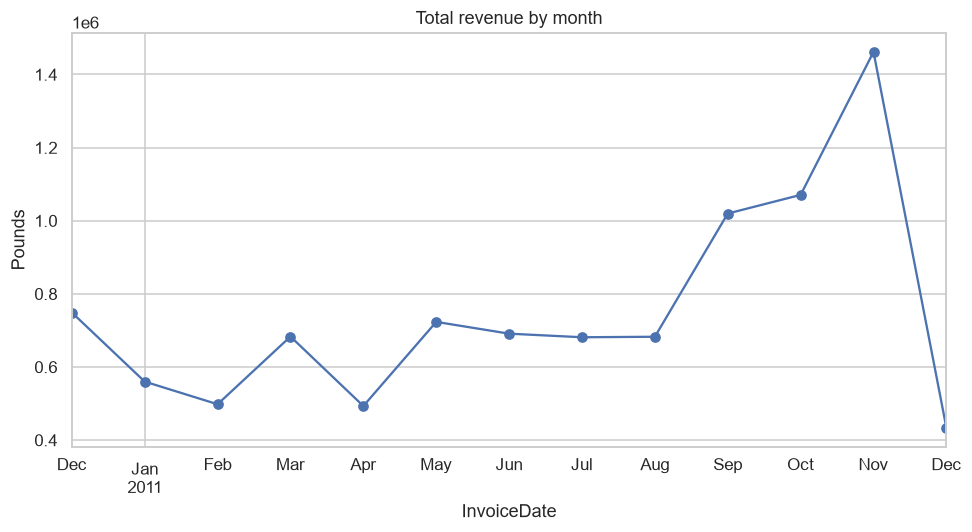

saved -> members\member-1\figures\q5_monthly_revenue.png
InvoiceDate
2010-12-31     748,957.02
2011-01-31     560,000.26
2011-02-28     498,062.65
2011-03-31     683,267.08
2011-04-30     493,207.12
2011-05-31     723,333.51
2011-06-30     691,123.12
2011-07-31     681,300.11
2011-08-31     682,680.51
2011-09-30   1,019,687.62
2011-10-31   1,070,704.67
2011-11-30   1,461,756.25
2011-12-31     433,668.01
Freq: ME, Name: LineTotal, dtype: float64

Note: Dec 2010 and Dec 2011 are both partial months.
[Q5] Seasonality
OBSERVATION: Revenue climbs steeply to a peak in November 2011, then drops in the partial December.
MEANING    : The business is highly seasonal around Christmas.
IMPACT     : M4 must note the 90-day test window (Sep-Dec) contains the Christmas peak, so repeat-purchase rates there exceed a normal quarter. Belongs in limitations.


In [17]:
monthly = df.set_index("InvoiceDate").LineTotal.resample("ME").sum()

ax = monthly.plot(marker="o", color="#4C72B0")
ax.set_title("Total revenue by month")
ax.set_ylabel("Pounds")
save("q5_monthly_revenue")

print(monthly)
print("\nNote: Dec 2010 and Dec 2011 are both partial months.")

insight("Q5", "Seasonality",
 "Revenue climbs steeply to a peak in November 2011, then drops in the partial December.",
 "The business is highly seasonal around Christmas.",
 "M4 must note the 90-day test window (Sep-Dec) contains the Christmas peak, so repeat-purchase rates there exceed a normal quarter. Belongs in limitations.")

## Q6. Where do customers come from?

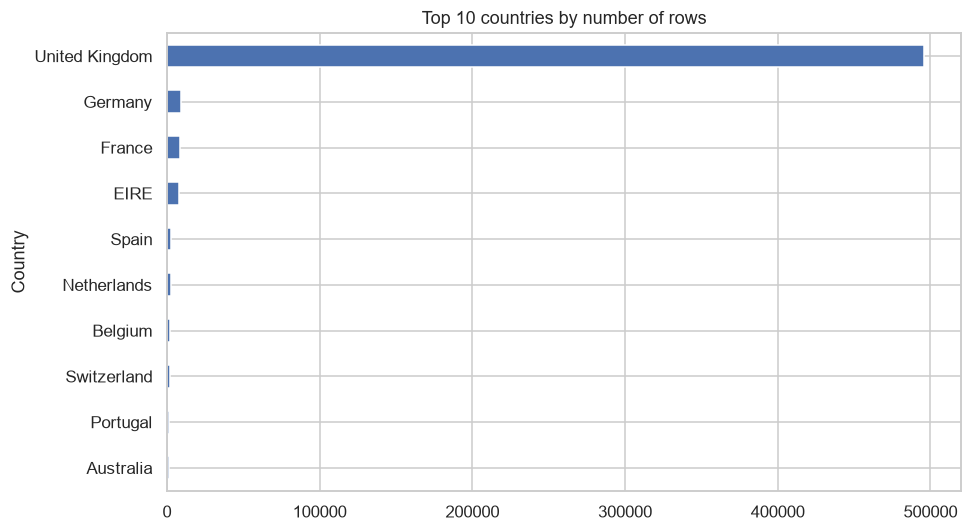

saved -> members\member-1\figures\q6_countries.png
United Kingdom share of rows: 91.4%
Distinct countries: 38
Vague or grouped values present: ['EIRE', 'Unspecified', 'European Community']
[Q6] Country imbalance
OBSERVATION: 91.4% of rows are from the United Kingdom, and some values are vague (EIRE, Unspecified, European Community).
MEANING    : Country is badly imbalanced and partly unreliable.
IMPACT     : M2 should collapse Country to UK / non-UK rather than one-hot encoding many values, which would add noise to distance-based clustering.


In [18]:
top = df.Country.value_counts().head(10)

ax = top.plot(kind="barh", color="#4C72B0")
ax.set_title("Top 10 countries by number of rows")
ax.invert_yaxis()
save("q6_countries")

uk = (df.Country == "United Kingdom").mean() * 100
print(f"United Kingdom share of rows: {uk:.1f}%")
print(f"Distinct countries: {df.Country.nunique()}")
vague = [x for x in df.Country.unique() if x in ("Unspecified", "European Community", "EIRE")]
print("Vague or grouped values present:", vague)

insight("Q6", "Country imbalance",
 f"{uk:.1f}% of rows are from the United Kingdom, and some values are vague ({', '.join(vague) if vague else 'e.g. Unspecified'}).",
 "Country is badly imbalanced and partly unreliable.",
 "M2 should collapse Country to UK / non-UK rather than one-hot encoding many values, which would add noise to distance-based clustering.")

## Q7. How common are cancellations?

In [19]:
df["IsCancel"] = df.InvoiceNo.astype(str).str.startswith("C")
canc_rows = df.IsCancel.sum()
canc_inv = df.loc[df.IsCancel, "InvoiceNo"].nunique()

print(f"Cancelled rows    : {canc_rows:,} ({canc_rows/len(df)*100:.2f}%)")
print(f"Cancelled invoices: {canc_inv:,}")
print(f"All cancelled rows have negative Quantity: {(df.loc[df.IsCancel,'Quantity'] < 0).all()}")
display(df[df.IsCancel].head(5))

cust = df.dropna(subset=["CustomerID"])
rate = cust.groupby("CustomerID").IsCancel.mean()
print(f"\nCustomers who ever cancelled: {(rate > 0).sum():,} of {len(rate):,}")

insight("Q7", "Cancellations",
 f"{canc_rows:,} rows ({canc_rows/len(df)*100:.2f}%) are cancellations with negative quantities, and {(rate>0).sum():,} customers cancelled at least once.",
 "Returns are a real, measurable part of buying behaviour, not merely dirty data.",
 "M2 must exclude them from spending totals so returns are not counted as sales. M3 may optionally test a cancellation-rate feature.")

Cancelled rows    : 9,288 (1.71%)
Cancelled invoices: 3,836
All cancelled rows have negative Quantity: True


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,LineTotal,IsCancel
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,"14,527.00",United Kingdom,-27.50,True
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,"15,311.00",United Kingdom,-4.65,True
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,"17,548.00",United Kingdom,-19.80,True
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,-6.96,True
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,-6.96,True



Customers who ever cancelled: 1,589 of 4,372
[Q7] Cancellations
OBSERVATION: 9,288 rows (1.71%) are cancellations with negative quantities, and 1,589 customers cancelled at least once.
MEANING    : Returns are a real, measurable part of buying behaviour, not merely dirty data.
IMPACT     : M2 must exclude them from spending totals so returns are not counted as sales. M3 may optionally test a cancellation-rate feature.


## Q8. Are there impossible values?

In [20]:
print(df[["Quantity","UnitPrice"]].describe())

print(f"\nRows with Quantity <= 0 : {(df.Quantity <= 0).sum():,}")
print(f"Rows with UnitPrice <= 0: {(df.UnitPrice <= 0).sum():,}")
print(f"Rows with UnitPrice <  0: {(df.UnitPrice < 0).sum():,}")

print("\nMost extreme rows:")
display(df.reindex(df.Quantity.abs().nlargest(4).index))

insight("Q8", "Impossible values",
 f"Quantity runs from {df.Quantity.min():,} to {df.Quantity.max():,} and UnitPrice from {df.UnitPrice.min():,.2f} to {df.UnitPrice.max():,.2f}; the extremes are a huge order and its matching cancellation.",
 "Some rows are accounting corrections rather than genuine sales.",
 "M2 removes non-positive prices and quantities using a documented rule. M1 keeps the evidence that these extremes are paired order/cancellation rows, not typos.")

        Quantity  UnitPrice
count 541,909.00 541,909.00
mean        9.55       4.61
std       218.08      96.76
min   -80,995.00 -11,062.06
25%         1.00       1.25
50%         3.00       2.08
75%        10.00       4.13
max    80,995.00  38,970.00

Rows with Quantity <= 0 : 10,624
Rows with UnitPrice <= 0: 2,517
Rows with UnitPrice <  0: 2

Most extreme rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,LineTotal,IsCancel
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,"16,446.00",United Kingdom,"168,469.60",False
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,"16,446.00",United Kingdom,"-168,469.60",True
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,"12,346.00",United Kingdom,"77,183.60",False
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,"12,346.00",United Kingdom,"-77,183.60",True


[Q8] Impossible values
OBSERVATION: Quantity runs from -80,995 to 80,995 and UnitPrice from -11,062.06 to 38,970.00; the extremes are a huge order and its matching cancellation.
MEANING    : Some rows are accounting corrections rather than genuine sales.
IMPACT     : M2 removes non-positive prices and quantities using a documented rule. M1 keeps the evidence that these extremes are paired order/cancellation rows, not typos.


## Q9. Which stock codes are not products?

In [21]:
codes = df.StockCode.astype(str)
odd = codes[~codes.str.match(r"^\d{5}")].value_counts().head(15)
display(odd)

for code_ in odd.index[:6]:
    desc = df.loc[codes == code_, "Description"].dropna().unique()[:2]
    print(f"{code_:<15} {desc}")

insight("Q9", "Non-product codes",
 f"{odd.sum():,} rows use non-product codes such as {', '.join(odd.index[:4])} for postage, discounts, manual adjustments and bank charges.",
 "Not every row is a product sale.",
 "M2 filters these from product-level analysis. OPEN QUESTION for the group: does postage count towards a customer's Monetary value? Record the answer in the decision log.")

StockCode
POST            1256
DOT              710
M                571
C2               144
D                 77
S                 63
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
DCGSSGIRL         13
DCGSSBOY          11
gift_0001_20      10
gift_0001_10       9
gift_0001_30       8
DCGS0003           5
Name: count, dtype: int64

POST            ['POSTAGE']
DOT             ['DOTCOM POSTAGE']
M               ['Manual']
C2              ['CARRIAGE']
D               ['Discount']
S               ['SAMPLES']
[Q9] Non-product codes
OBSERVATION: 2,964 rows use non-product codes such as POST, DOT, M, C2 for postage, discounts, manual adjustments and bank charges.
MEANING    : Not every row is a product sale.
IMPACT     : M2 filters these from product-level analysis. OPEN QUESTION for the group: does postage count towards a customer's Monetary value? Record the answer in the decision log.


## Q10. Are products cheap or expensive?

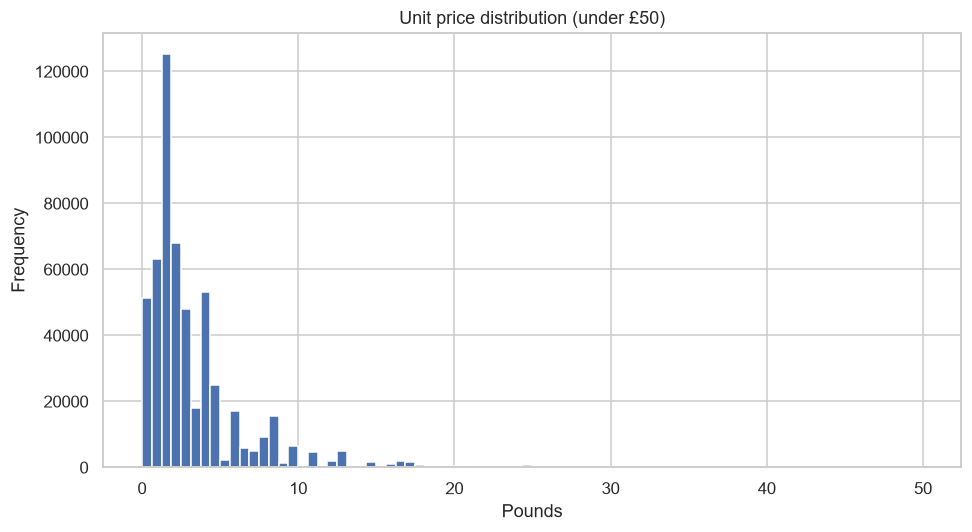

saved -> members\member-1\figures\q10_unit_price.png
count   539,392.00
mean          4.67
std          94.61
min           0.00
25%           1.25
50%           2.08
75%           4.13
max      38,970.00
Name: UnitPrice, dtype: float64

Items under £5: 83.3% of rows
[Q10] Low unit prices
OBSERVATION: Most items are inexpensive gifts; the median unit price is about £2.08.
MEANING    : High customer spend comes from buying in bulk, not from buying expensive items.
IMPACT     : Supports the wholesaler explanation in Q2 and helps M4 name clusters accurately ('bulk buyers', not 'luxury buyers').


In [22]:
prices = df.loc[(df.UnitPrice > 0) & (df.UnitPrice < 50), "UnitPrice"]

ax = prices.plot(kind="hist", bins=80, color="#4C72B0")
ax.set_title("Unit price distribution (under \u00a350)")
ax.set_xlabel("Pounds")
save("q10_unit_price")

median_price = df.loc[df.UnitPrice > 0, "UnitPrice"].median()
print(df.loc[df.UnitPrice > 0, "UnitPrice"].describe())
print(f"\nItems under \u00a35: {df.UnitPrice.between(0.01, 5).mean()*100:.1f}% of rows")

insight("Q10", "Low unit prices",
 f"Most items are inexpensive gifts; the median unit price is about \u00a3{median_price:.2f}.",
 "High customer spend comes from buying in bulk, not from buying expensive items.",
 "Supports the wholesaler explanation in Q2 and helps M4 name clusters accurately ('bulk buyers', not 'luxury buyers').")

## Q11. Do the three RFM measures overlap?

If two measures say the same thing, the clustering uses fewer real dimensions than
you claim. M3 needs to know this.

Preview RFM table (full data — M3 rebuilds this using the cut-off date):


,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00"
mean,92.54,4.27,"2,054.27"
std,100.01,7.70,"8,989.23"
min,1.00,1.00,3.75
25%,18.00,1.00,307.41
50%,51.00,2.00,674.49
75%,142.00,5.00,"1,661.74"
max,374.00,209.00,"280,206.02"


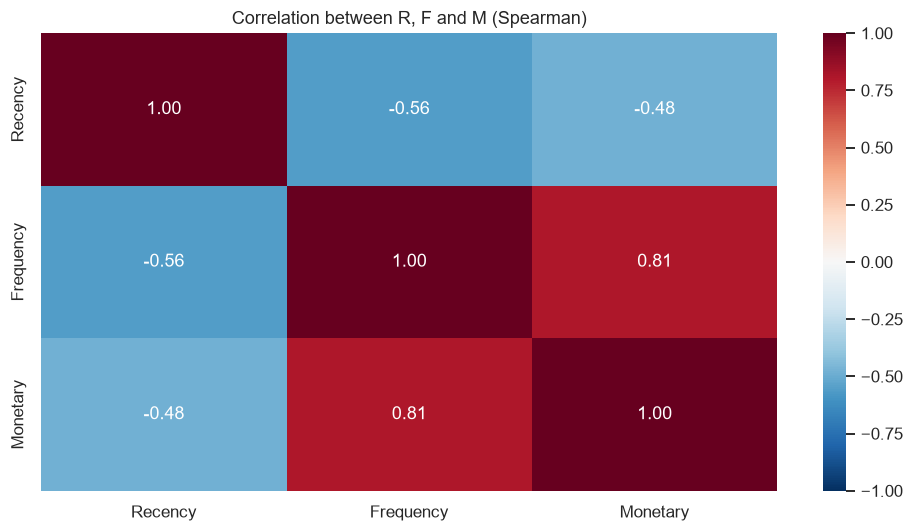

saved -> members\member-1\figures\q11_rfm_correlation.png
           Recency  Frequency  Monetary
Recency       1.00      -0.56     -0.48
Frequency    -0.56       1.00      0.81
Monetary     -0.48       0.81      1.00
[Q11] R, F, M overlap
OBSERVATION: Frequency and Monetary are strongly correlated (Spearman 0.81); Recency relates negatively to both.
MEANING    : F and M partly measure the same underlying loyalty, so the three measures are not independent.
IMPACT     : M3 scales all three so none dominates, and mentions this overlap when interpreting clusters. Adding further spend-related features would worsen the redundancy.


In [23]:
clean = df[(~df.IsCancel) & df.CustomerID.notna() &
           (df.Quantity > 0) & (df.UnitPrice > 0)].copy()
snapshot = clean.InvoiceDate.max() + pd.Timedelta(days=1)

rfm = clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("LineTotal", "sum"),
)
print("Preview RFM table (full data — M3 rebuilds this using the cut-off date):")
display(rfm.describe())

corr = rfm.corr(method="spearman")
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation between R, F and M (Spearman)")
save("q11_rfm_correlation")

print(corr)

insight("Q11", "R, F, M overlap",
 f"Frequency and Monetary are strongly correlated (Spearman {corr.loc['Frequency','Monetary']:.2f}); Recency relates negatively to both.",
 "F and M partly measure the same underlying loyalty, so the three measures are not independent.",
 "M3 scales all three so none dominates, and mentions this overlap when interpreting clusters. Adding further spend-related features would worsen the redundancy.")

## Q12. Are there exact duplicate rows?

In [24]:
dups = df.duplicated().sum()
print(f"Exact duplicate rows: {dups:,} ({dups/len(df)*100:.2f}%)")
if dups:
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns[:6])).head(6))

insight("Q12", "Duplicate rows",
 f"{dups:,} rows are exact duplicates of another row.",
 "The same product line was recorded twice, so quantities and totals are slightly inflated.",
 "M2 applies drop_duplicates() before building any totals, otherwise Frequency and Monetary are overstated for the affected customers.")

Exact duplicate rows: 5,268 (0.97%)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,LineTotal,IsCancel
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,"17,908.00",United Kingdom,1.25,False
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,"17,908.00",United Kingdom,1.25,False
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,"17,908.00",United Kingdom,4.95,False
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,"17,908.00",United Kingdom,4.95,False
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,"17,908.00",United Kingdom,2.10,False
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,"17,908.00",United Kingdom,2.10,False


[Q12] Duplicate rows
OBSERVATION: 5,268 rows are exact duplicates of another row.
MEANING    : The same product line was recorded twice, so quantities and totals are slightly inflated.
IMPACT     : M2 applies drop_duplicates() before building any totals, otherwise Frequency and Monetary are overstated for the affected customers.


## 3. Build the EDA insight log

Every `insight(...)` call above was collected automatically. This writes them out.

In [25]:
log = pd.DataFrame(INSIGHTS)
display(log)

log_path = MY_DOCS / "eda_insight_log.csv"
log.to_csv(log_path, index=False)
print("saved ->", log_path.relative_to(ROOT))
print(f"{len(log)} insights recorded.")

,Ref,Topic,Observation,Meaning,Impact
0,Q1,Missing CustomerID,"135,080 rows (24.9%) have no CustomerID.",These are likely guest or till sales that cann...,M2 drops them for customer-level work. M1 reco...
1,Q2,Spend skew,Spend is extremely right-skewed (skewness 21.6...,A small number of wholesalers spend far more t...,M2 should log-transform Monetary before scalin...
2,Q3,One-time buyers,"1,313 customers (30.0%) placed only one order.",A large one-time group exists alongside a smal...,M3 should expect at least one cluster of one-t...
3,Q4,Recency spread,Recency ranges from 0 to 373 days; the median ...,Many customers have been quiet a long time whi...,"Recency separates customers well, so M3 keeps ..."
4,Q5,Seasonality,Revenue climbs steeply to a peak in November 2...,The business is highly seasonal around Christmas.,M4 must note the 90-day test window (Sep-Dec) ...
5,Q6,Country imbalance,"91.4% of rows are from the United Kingdom, and...",Country is badly imbalanced and partly unrelia...,M2 should collapse Country to UK / non-UK rath...
6,Q7,Cancellations,"9,288 rows (1.71%) are cancellations with nega...","Returns are a real, measurable part of buying ...",M2 must exclude them from spending totals so r...
7,Q8,Impossible values,"Quantity runs from -80,995 to 80,995 and UnitP...",Some rows are accounting corrections rather th...,M2 removes non-positive prices and quantities ...
8,Q9,Non-product codes,"2,964 rows use non-product codes such as POST,...",Not every row is a product sale.,M2 filters these from product-level analysis. ...
9,Q10,Low unit prices,Most items are inexpensive gifts; the median u...,"High customer spend comes from buying in bulk,...",Supports the wholesaler explanation in Q2 and ...


saved -> members\member-1\docs\eda_insight_log.csv
12 insights recorded.


## 4. Promote accepted outputs to the shared folders

Run this **only after the group has reviewed your work**. It copies your figures and
logs from `members/member-1/` into the shared `figures/eda/` and `docs/` folders.

In [26]:
import shutil

REVIEWED_AND_ACCEPTED = False   # set to True after group review

if not REVIEWED_AND_ACCEPTED:
    print("Skipped. Set REVIEWED_AND_ACCEPTED = True once the group has reviewed these outputs.")
else:
    n = 0
    for png in sorted(MY_FIGURES.glob("*.png")):
        shutil.copy2(png, SHARED_FIG / png.name)
        n += 1
    shutil.copy2(MY_DOCS / "data_dictionary_raw.csv", SHARED_DICT / "data_dictionary_raw.csv")
    shutil.copy2(MY_DOCS / "eda_insight_log.csv", SHARED_LOG / "eda_insight_log.csv")
    print(f"Promoted {n} figures to {SHARED_FIG.relative_to(ROOT)}")
    print("Promoted data dictionary to", SHARED_DICT.relative_to(ROOT))
    print("Promoted insight log to", SHARED_LOG.relative_to(ROOT))

Skipped. Set REVIEWED_AND_ACCEPTED = True once the group has reviewed these outputs.


## 5. Handover to Member 2

Give Member 2 the insight log and the figures. Each preprocessing decision they make
should cite a **Q-number** from this notebook as its evidence — that traceability is
what the marking rubric rewards.

**Open question for the group (from Q9):** does postage count towards a customer's
Monetary value? Decide it, then record the options and the reason in
`docs/decision-log/`.

**Before you hand over:** restart the kernel and run everything top to bottom once, so
the outputs here match what you write in the report.